# NFL Big Data Bowl 2026  
## 04 – Predictive Modeling of Play Effectiveness (RQ2 & RQ3)

This notebook addresses **Research Questions 2 and 3** by developing predictive models for play effectiveness, measured by **yards gained**.

We combine:
- contextual play information,
- offensive route design,
- defensive coverage schemes,
- and engineered movement-based features

to identify which factors are most predictive of yards gained on passing plays.

> **Important methodological note:**  
> The **tracking input** data ends at the **throw** (pre-throw).  
> The **target** (`yards_gained`) is observed after the play ends.  
> We therefore build a *pre-throw → outcome* supervised regression model and avoid post-throw leakage.


## Research Questions

**RQ2 – Route Design and Play Effectiveness**

> How do different route types influence play effectiveness, measured by yards gained, and which route-related movement features are most predictive?

**RQ3 – Defensive Coverage and Play Effectiveness**

> How do defensive coverage schemes (man vs zone) influence play effectiveness, measured by yards gained, and which coverage-related movement features are most predictive?

Both questions are answered using supervised machine learning models trained on the **final modeling dataset** produced in Notebook 03.


In [1]:
# 1) Imports & settings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from scipy.stats import mannwhitneyu, kruskal

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

sns.set_theme(style="whitegrid")

palette_routes = sns.color_palette("tab10")
palette_cov = ["#1f77b4", "#ff7f0e"]

TRAIN_COLOR = "#5B2A86"
TEST_COLOR = "#1B998B"
EDGE_COLOR = "black"

plt.rcParams["figure.figsize"] = (10, 6)

PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data"
FIG_DIR = PROJECT_ROOT / "figures"
TAB_DIR = PROJECT_ROOT / "tables"
FIG_DIR.mkdir(exist_ok=True, parents=True)
TAB_DIR.mkdir(exist_ok=True, parents=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_DIR:", DATA_DIR)
print("FIG_DIR:", FIG_DIR)
print("TAB_DIR:", TAB_DIR)


PROJECT_ROOT: /Users/siamsadman/Git_Projects/git-projects/statistical_consulting_project/nfl_big_data_bowl_2026/nfl-yards-gained-prediction
DATA_DIR: /Users/siamsadman/Git_Projects/git-projects/statistical_consulting_project/nfl_big_data_bowl_2026/nfl-yards-gained-prediction/data
FIG_DIR: /Users/siamsadman/Git_Projects/git-projects/statistical_consulting_project/nfl_big_data_bowl_2026/nfl-yards-gained-prediction/figures
TAB_DIR: /Users/siamsadman/Git_Projects/git-projects/statistical_consulting_project/nfl_big_data_bowl_2026/nfl-yards-gained-prediction/tables


In [2]:
# Helper to save LaTeX-ready tables

def save_table(df: pd.DataFrame, name: str, index: bool = False, float_format: str = "%.3f"):
    csv_path = TAB_DIR / f"{name}.csv"
    tex_path = TAB_DIR / f"{name}.tex"
    df.to_csv(csv_path, index=index)
    tex = df.to_latex(index=index, escape=True, float_format=float_format)
    tex_path.write_text(tex, encoding="utf-8")
    print(f"Saved table: {csv_path.name}, {tex_path.name}")


## 2. Load final modeling dataset

We load the play-level modeling table from Notebook 03.  
This table is designed to have **one row per passing play (targeted receiver context)**, with:

- contextual variables (down, distance, field position, etc.)
- route and coverage information (RQ2/RQ3)
- engineered pre-throw movement features (defender distances, angles, closing velocity, etc.)
- target: `yards_gained`


In [3]:
# 2) Load model table

model_path = DATA_DIR / "processed"/ "model_table_yards.parquet"
if not model_path.exists():
    raise FileNotFoundError(f"Could not find: {model_path}")

model_df = pd.read_parquet(model_path)

print("Model table shape:", model_df.shape)
display(model_df.head())


Model table shape: (14108, 100)


,game_id,play_id,nfl_id_wr,ref_frame_id,wr_x,wr_y,wr_s,wr_a,wr_dir,wr_o,...,sep_min,sep_mean,sep_std,sep_p25,sep_p50,sep_p75,frac_sep_below_1,frac_sep_below_2,frac_sep_below_3,sep_at_throw
0,2023090700,101,44930,26,52.43,14.14,7.90,2.68,99.25,106.80,...,1.066771,2.770382,1.011555,1.872267,3.073829,3.559012,0.0,0.269231,0.461538,4.735652
1,2023090700,194,41325,32,88.98,22.23,6.09,2.14,245.74,314.63,...,1.001798,4.189085,2.509043,1.736266,4.102659,6.671739,0.0,0.343750,0.406250,1.883215
2,2023090700,219,53591,17,75.98,10.22,3.85,2.77,268.92,343.54,...,4.906832,5.927040,0.637236,5.363283,6.049876,6.554121,0.0,0.000000,0.000000,4.906832
3,2023090700,361,38696,51,34.19,48.33,1.51,3.87,18.99,194.89,...,2.143105,6.057146,3.590496,2.667735,4.921839,9.967827,0.0,0.000000,0.352941,2.180138
4,2023090700,436,53541,20,33.67,37.80,3.59,6.08,116.90,136.35,...,2.872786,4.648680,1.019285,3.785929,4.910604,5.648982,0.0,0.000000,0.050000,2.872786


### Quick sanity checks

- `yards_gained` should be numeric
- route and coverage columns should exist
- week or game_date should exist for time-aware validation


In [4]:
# 2.1) Sanity checks

assert "yards_gained" in model_df.columns, "Missing target: yards_gained"
print("yards_gained dtype:", model_df["yards_gained"].dtype)

expected_cols = ["route_of_targeted_receiver", "team_coverage_man_zone"]
for c in expected_cols:
    print(c, "exists?", c in model_df.columns)

time_cols = [c for c in ["week", "game_date"] if c in model_df.columns]
print("Available time columns:", time_cols)

display(model_df[expected_cols + ["yards_gained"]].head() if all(c in model_df.columns for c in expected_cols) else model_df[["yards_gained"]].head())


yards_gained dtype: int64
route_of_targeted_receiver exists? True
team_coverage_man_zone exists? True
Available time columns: ['week']


,route_of_targeted_receiver,team_coverage_man_zone,yards_gained
0,CORNER,ZONE_COVERAGE,0
1,ANGLE,MAN_COVERAGE,10
2,HITCH,ZONE_COVERAGE,5
3,HITCH,ZONE_COVERAGE,5
4,SLANT,MAN_COVERAGE,13


## 3. Target Variable: Yards Gained

The target variable for all predictive models is **`yards_gained`**, which measures how far the offense advanced the ball on the play.

Why `yards_gained` is a useful measure of effectiveness:

- it directly contributes to **first downs** and **field position**
- it reflects both **catch success** and **yards after the catch (YAC)**
- it is a **continuous** outcome suited to regression modeling


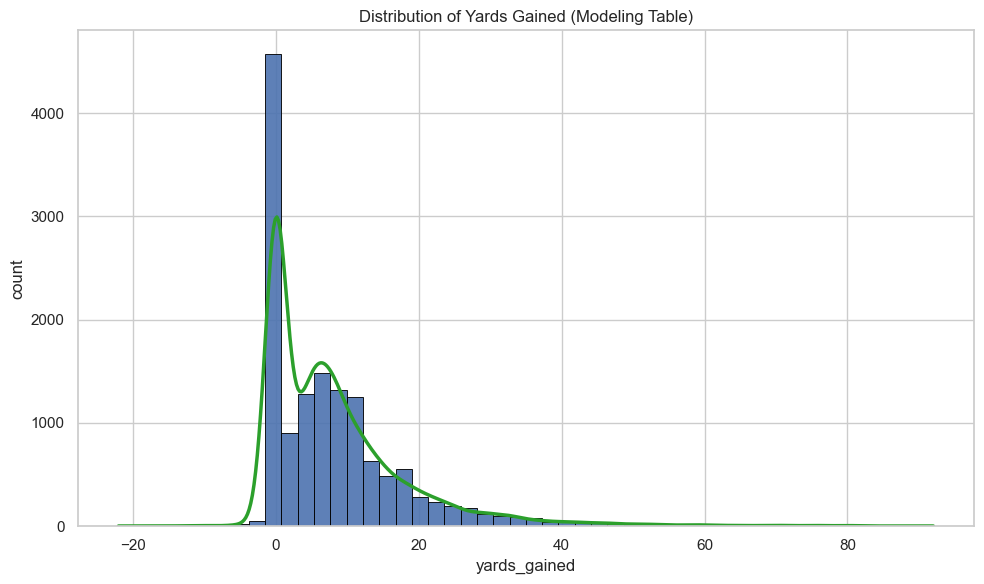

In [5]:
# 3.1) Distribution of yards gained

from scipy.stats import gaussian_kde

PRIMARY_BLUE = "#4C72B0"

yg = model_df["yards_gained"].dropna()

plt.figure(figsize=(10,6))

counts, bins, _ = plt.hist(
    yg,
    bins=50,
    color=PRIMARY_BLUE,
    edgecolor="black",
    linewidth=0.7,
    alpha=0.9
)

# KDE scaled to histogram
kde = gaussian_kde(yg)
x_vals = np.linspace(yg.min(), yg.max(), 500)
bin_width = bins[1] - bins[0]

plt.plot(
    x_vals,
    kde(x_vals) * len(yg) * bin_width,
    color="#2ca02c",
    linewidth=2.5
)

plt.title("Distribution of Yards Gained (Modeling Table)")
plt.xlabel("yards_gained")
plt.ylabel("count")

plt.tight_layout()
plt.show()

## 4. RQ2 – Exploratory Analysis: Route Types

We begin by examining how `yards_gained` varies across different **route types**.
This provides descriptive context before formal statistical testing and modeling.


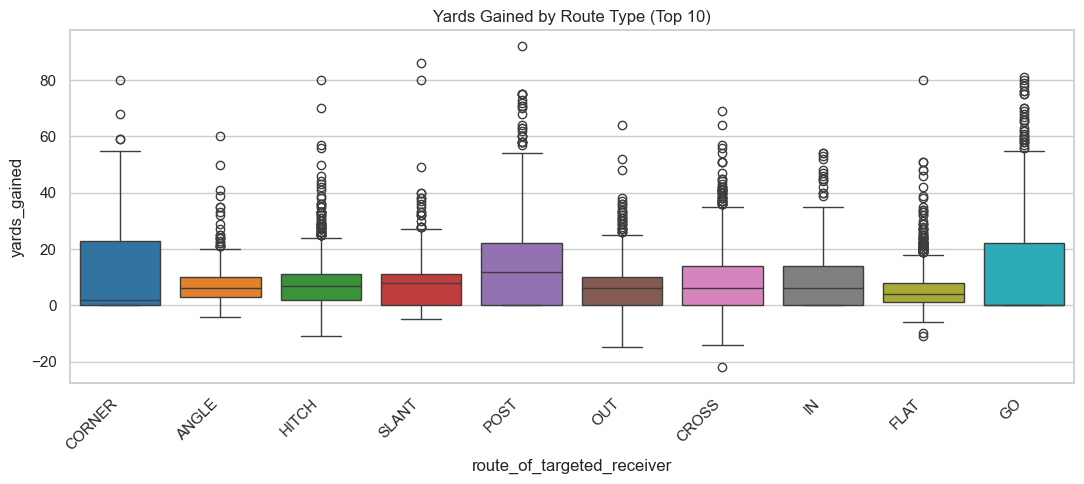

In [6]:
# 4.1) Route boxplots (Top 10 routes by frequency)

top_routes = None

if "route_of_targeted_receiver" in model_df.columns:
    top_routes = model_df["route_of_targeted_receiver"].value_counts().head(10).index

    plt.figure(figsize=(11, 5))
    sns.boxplot(
    data=model_df[model_df["route_of_targeted_receiver"].isin(top_routes)],
    x="route_of_targeted_receiver",
    y="yards_gained",
    hue="route_of_targeted_receiver",
    palette=palette_routes,
    legend=False
    )
    plt.xticks(rotation=45, ha="right")
    plt.title("Yards Gained by Route Type (Top 10)")
    plt.tight_layout()
    plt.show()

else:
    print("route_of_targeted_receiver not available in model_df.")


## 5. RQ2 – Statistical Comparison Across Route Types (Kruskal–Wallis)

To test whether yards gained differs across route types, we use a **Kruskal–Wallis test**  
(non-parametric alternative to one-way ANOVA; does not assume normality).

- **H0:** all route types have the same yards_gained distribution
- **H1:** at least one route type differs


In [7]:
# 5.1) Kruskal–Wallis test (Top routes)

if top_routes is not None:
    route_groups = [
        model_df.loc[model_df["route_of_targeted_receiver"] == r, "yards_gained"].dropna()
        for r in top_routes
    ]
    kw_stat, kw_p = kruskal(*route_groups)
    print("Kruskal–Wallis statistic:", kw_stat)
    print("p-value:", kw_p)

    route_test_df = pd.DataFrame({
        "Test": ["Kruskal-Wallis (Top Routes)"],
        "Statistic": [kw_stat],
        "p_value": [kw_p]
    })
    save_table(route_test_df.round(4), "table6_kruskal", index=False, float_format="%.4f")
else:
    kw_stat, kw_p = np.nan, np.nan
    print("route_of_targeted_receiver not available in model_df.")


Kruskal–Wallis statistic: 170.8965936004383
p-value: 4.0136234959127783e-32
Saved table: table6_kruskal.csv, table6_kruskal.tex


## 6. RQ3 – Exploratory Analysis: Man vs Zone Coverage

Next, we examine how `yards_gained` differs between **man** and **zone** coverage schemes.


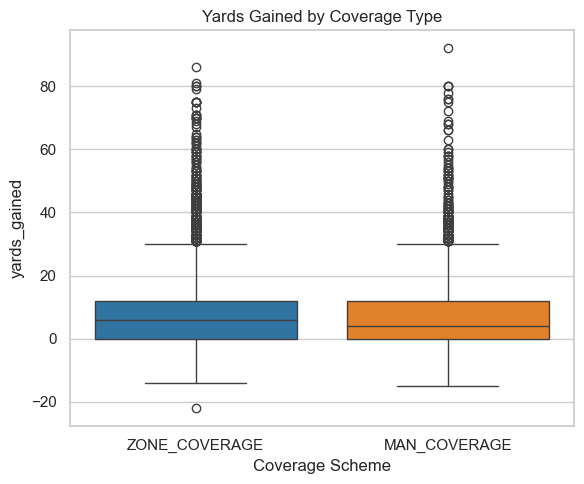

In [8]:
# 6.1) Coverage boxplot

if "team_coverage_man_zone" in model_df.columns:
    plt.figure(figsize=(6, 5))
    sns.boxplot(
    data=model_df,
    x="team_coverage_man_zone",
    y="yards_gained",
    hue="team_coverage_man_zone",
    palette=palette_cov,
    legend=False
    )
    plt.xlabel("Coverage Scheme")
    plt.title("Yards Gained by Coverage Type")
    plt.tight_layout()
    plt.show()

else:
    print("team_coverage_man_zone not available in model_df.")


## 7. RQ3 – Statistical Comparison: Man vs Zone (Mann–Whitney U)

Because this is a two-group comparison, we use the **Mann–Whitney U test**.

- **H0:** Man and Zone have the same yards_gained distribution
- **H1:** Distributions differ


In [9]:
# 7.1) Mann–Whitney U test

coverage_counts = model_df["team_coverage_man_zone"].value_counts(dropna=False)
print(coverage_counts)

man = model_df.loc[
    model_df["team_coverage_man_zone"] == "MAN_COVERAGE",
    "yards_gained"
].dropna()

zone = model_df.loc[
    model_df["team_coverage_man_zone"] == "ZONE_COVERAGE",
    "yards_gained"
].dropna()

print("Man n:", len(man))
print("Zone n:", len(zone))

if len(man) > 10 and len(zone) > 10:
    u_stat, u_p = mannwhitneyu(man, zone, alternative="two-sided")
    print("U statistic:", u_stat)
    print("p-value:", u_p)

    mw_df = pd.DataFrame({
        "Test": ["Mann-Whitney (Man vs Zone)"],
        "U_statistic": [u_stat],
        "p_value": [u_p]
    })
    save_table(mw_df.round(4), "table6_mannwhitney", index=False, float_format="%.4f")
else:
    u_stat, u_p = np.nan, np.nan
    print("Still not enough valid data for reliable test.")


team_coverage_man_zone
ZONE_COVERAGE    10092
MAN_COVERAGE      4013
NaN                  3
Name: count, dtype: int64
Man n: 4013
Zone n: 10092
U statistic: 18554235.0
p-value: 2.7179333104400583e-15
Saved table: table6_mannwhitney.csv, table6_mannwhitney.tex


# 8. Modeling (RQ2 & RQ3)

We now build supervised regression models to predict `yards_gained` from **pre-throw** features.

### Leakage control
We **exclude** outcome-like columns such as:
- `yards_gained` (target)
- `pass_result` (outcome label)
- any post-throw information (if present)

### Models
We compare:
- **Linear Regression** (interpretable baseline)
- **Random Forest Regressor** (nonlinear baseline)
- **XGBoost Regressor** (strong boosted-tree model; falls back to HistGradientBoosting if unavailable)

### Validation
We use:
- **Time-aware train/test split** (train on earlier weeks/games, test on later)
- **TimeSeriesSplit cross-validation** (rolling splits)


In [10]:
# 8.1) Define target + feature columns (drop leakage)

target = "yards_gained"

drop_cols = ["yards_gained", "pass_result"]
for c in ["ball_land_x", "ball_land_y"]:
    if c in model_df.columns:
        drop_cols.append(c)

feature_df = model_df.drop(columns=drop_cols, errors="ignore")
y = model_df[target].copy()

cat_cols = feature_df.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = [c for c in feature_df.columns if c not in cat_cols]

print("Num cols:", len(num_cols), "Cat cols:", len(cat_cols))
print("Dropped cols:", drop_cols)


Num cols: 86 Cat cols: 10
Dropped cols: ['yards_gained', 'pass_result', 'ball_land_x', 'ball_land_y']


/var/folders/5z/gzwjpfn96n1363rb0kbjncwh0000gn/T/ipykernel_75695/3797568124.py:13: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = feature_df.select_dtypes(include=["object", "category"]).columns.tolist()


In [11]:
# 8.2) Preprocessing pipeline (impute + one-hot inside the pipeline)

preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
        ]), num_cols),
        ("cat", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore")),
        ]), cat_cols),
    ]
)


In [12]:
# 8.3) Helper: evaluation metrics

def eval_regression(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    r2 = r2_score(y_true, y_pred)
    return {"MAE": mae, "RMSE": rmse, "R2": r2}


## 9. Time-aware Train/Test Split

We sort by `week` (preferred) or `game_date` (fallback) and evaluate on the most recent portion of the season.
This more closely matches a real forecasting scenario than a random split.


In [13]:
# 9.1) Time-aware split

if "week" in model_df.columns:
    sort_col = "week"
elif "game_date" in model_df.columns:
    sort_col = "game_date"
    model_df = model_df.copy()
    model_df["game_date"] = pd.to_datetime(model_df["game_date"], errors="coerce")
else:
    raise ValueError("Need 'week' or 'game_date' column for time-aware split.")

df_sorted = model_df.sort_values(sort_col).reset_index(drop=True)

split_idx = int(len(df_sorted) * 0.75)

train_df = df_sorted.iloc[:split_idx].copy()
test_df = df_sorted.iloc[split_idx:].copy()

X_train_raw = train_df.drop(columns=drop_cols, errors="ignore")
y_train = train_df[target]

X_test_raw = test_df.drop(columns=drop_cols, errors="ignore")
y_test = test_df[target]

print("Time split by:", sort_col)
print("Train range:", train_df[sort_col].min(), "→", train_df[sort_col].max())
print("Test  range:", test_df[sort_col].min(), "→", test_df[sort_col].max())
print("Train size:", len(train_df), "Test size:", len(test_df))


Time split by: week
Train range: 1 → 14
Test  range: 14 → 18
Train size: 10581 Test size: 3527


Saved table: table6_time_split_summary.csv, table6_time_split_summary.tex


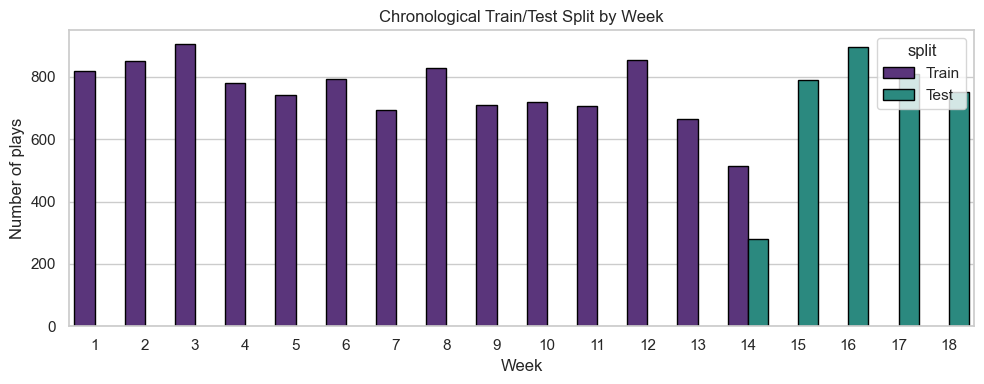

Saved: /Users/siamsadman/Git_Projects/git-projects/statistical_consulting_project/nfl_big_data_bowl_2026/nfl-yards-gained-prediction/figures/fig6_time_split_distribution.png


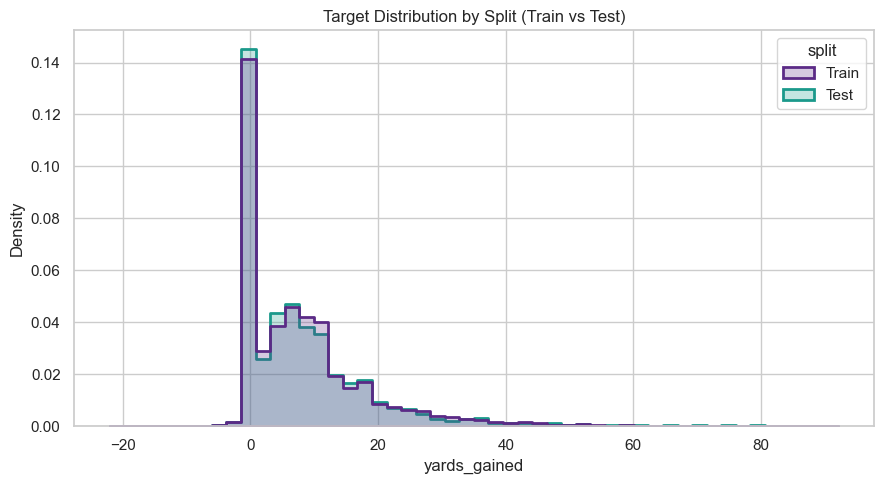

Saved: /Users/siamsadman/Git_Projects/git-projects/statistical_consulting_project/nfl_big_data_bowl_2026/nfl-yards-gained-prediction/figures/fig6_target_dist_train_test.png
Saved table: table6_target_desc_by_split.csv, table6_target_desc_by_split.tex


In [14]:
# 9.2) Export time-aware split figures and tables

# Summary table
train_min, train_max = train_df[sort_col].min(), train_df[sort_col].max()
test_min, test_max = test_df[sort_col].min(), test_df[sort_col].max()

split_summary = pd.DataFrame({
    "Split": ["Train", "Test"],
    "Observations": [len(train_df), len(test_df)],
    "TimeVariable": [sort_col, sort_col],
    "TimeRange": [f"{train_min} -- {train_max}", f"{test_min} -- {test_max}"],
})
save_table(split_summary, "table6_time_split_summary", index=False, float_format="%.0f")

# Time split figure
tmp = df_sorted[[sort_col]].copy()
tmp["split"] = ["Train"] * len(train_df) + ["Test"] * len(test_df)

plt.figure(figsize=(10, 4))
if sort_col == "week":
    sns.countplot(
    data=tmp,
    x=sort_col,
    hue="split",
    palette={"Train": TRAIN_COLOR, "Test": TEST_COLOR},
    edgecolor=EDGE_COLOR
    )
    plt.title("Chronological Train/Test Split by Week")
    plt.xlabel("Week")
    plt.ylabel("Number of plays")
else:
    tmp[sort_col] = pd.to_datetime(tmp[sort_col], errors="coerce")
    sns.histplot(
    data=tmp,
    x=sort_col,
    hue="split",
    element="step",
    stat="count",
    common_norm=False,
    bins=30,
    palette={"Train": TRAIN_COLOR, "Test": TEST_COLOR},
    linewidth=2
    )
    plt.title("Chronological Train/Test Split by Game Date")
    plt.xlabel("Game date")
    plt.ylabel("Number of plays")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig6_time_split_distribution.png", dpi=300)
plt.show()

print("Saved:", FIG_DIR / "fig6_time_split_distribution.png")

# Target distribution by split
tmp_y = pd.concat([
    train_df[[target]].assign(split="Train"),
    test_df[[target]].assign(split="Test")
], ignore_index=True)

plt.figure(figsize=(9, 5))
sns.histplot(
    data=tmp_y,
    x=target,
    hue="split",
    element="step",
    stat="density",
    common_norm=False,
    bins=50,
    palette={"Train": TRAIN_COLOR, "Test": TEST_COLOR},
    linewidth=2
)
plt.title("Target Distribution by Split (Train vs Test)")
plt.xlabel("yards_gained")
plt.ylabel("Density")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig6_target_dist_train_test.png", dpi=300)
plt.show()

print("Saved:", FIG_DIR / "fig6_target_dist_train_test.png")

# Target descriptive table
desc_train = train_df[target].describe()
desc_test = test_df[target].describe()

target_desc = pd.DataFrame({
    "Split": ["Train", "Test"],
    "n": [desc_train["count"], desc_test["count"]],
    "mean": [desc_train["mean"], desc_test["mean"]],
    "std": [desc_train["std"], desc_test["std"]],
    "min": [desc_train["min"], desc_test["min"]],
    "p25": [desc_train["25%"], desc_test["25%"]],
    "median": [desc_train["50%"], desc_test["50%"]],
    "p75": [desc_train["75%"], desc_test["75%"]],
    "max": [desc_train["max"], desc_test["max"]],
})
save_table(target_desc, "table6_target_desc_by_split", index=False)


## 10. Train & Compare Models (Time-split test)

We train each model on the earlier time period and evaluate on the later time period.


In [15]:
# 10.1) Define models

lin_model = Pipeline(steps=[
    ("prep", preprocess),
    ("model", LinearRegression())
])

rf_model = Pipeline(steps=[
    ("prep", preprocess),
    ("model", RandomForestRegressor(
        n_estimators=500,
        random_state=42,
        n_jobs=-1,
        max_depth=None
    ))
])

try:
    from xgboost import XGBRegressor
    xgb_model = Pipeline(steps=[
        ("prep", preprocess),
        ("model", XGBRegressor(
            n_estimators=900,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_lambda=1.0,
            random_state=42,
            n_jobs=-1,
        ))
    ])
    xgb_available = True
    print("Using XGBoost.")
except Exception as e:
    from sklearn.ensemble import HistGradientBoostingRegressor
    xgb_model = Pipeline(steps=[
        ("prep", preprocess),
        ("model", HistGradientBoostingRegressor(random_state=42))
    ])
    xgb_available = False
    print("XGBoost not available; using HistGradientBoostingRegressor instead.")
    print("Reason:", e)


Using XGBoost.


,Model,MAE,RMSE,R2
2,XGBoost/Boosting,6.465683,9.683908,0.141564
1,Random Forest,6.480849,9.745648,0.130583
0,Linear Regression,9.315163,12.806047,-0.501195


Saved table: table6_test_results.csv, table6_test_results.tex


/var/folders/5z/gzwjpfn96n1363rb0kbjncwh0000gn/T/ipykernel_75695/1985566990.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=test_results, x="Model", y="RMSE", palette="viridis")


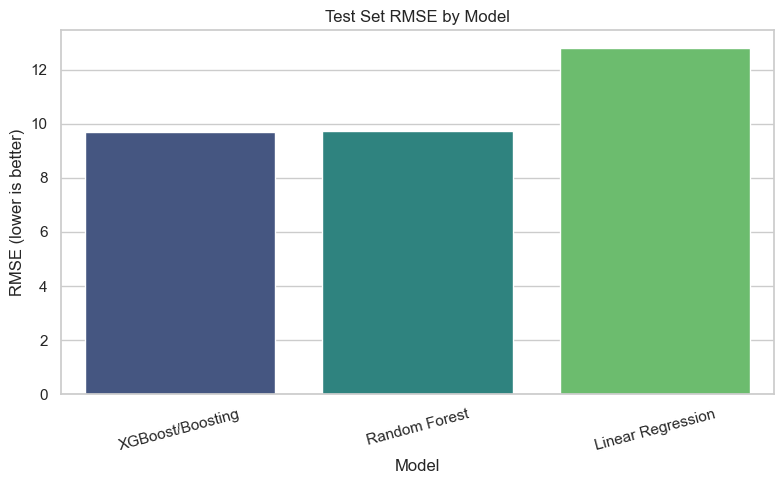

Saved: /Users/siamsadman/Git_Projects/git-projects/statistical_consulting_project/nfl_big_data_bowl_2026/nfl-yards-gained-prediction/figures/fig6_test_rmse.png


In [16]:
# 10.2) Fit + evaluate

results = []

for name, model in [
    ("Linear Regression", lin_model),
    ("Random Forest", rf_model),
    ("XGBoost/Boosting", xgb_model),
]:
    model.fit(X_train_raw, y_train)
    pred = model.predict(X_test_raw)
    m = eval_regression(y_test, pred)
    m["Model"] = name
    results.append(m)

test_results = pd.DataFrame(results)[["Model","MAE","RMSE","R2"]].sort_values("RMSE")
display(test_results)

save_table(test_results.round(3), "table6_test_results", index=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=test_results, x="Model", y="RMSE", palette="viridis")
plt.title("Test Set RMSE by Model")
plt.ylabel("RMSE (lower is better)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig6_test_rmse.png", dpi=300)
plt.show()

print("Saved:", FIG_DIR / "fig6_test_rmse.png")


## 11. Time-aware Cross-Validation (Rolling Splits)

We also run **TimeSeriesSplit** CV to reduce sensitivity to a single split.


In [17]:
# 11.1) TimeSeriesSplit CV

X_all_raw = df_sorted.drop(columns=drop_cols, errors="ignore")
y_all = df_sorted[target].copy()

tscv = TimeSeriesSplit(n_splits=5)

def cv_scores(model, X, y, splitter):
    rows = []
    for fold, (tr_idx, te_idx) in enumerate(splitter.split(X), start=1):
        X_tr, X_te = X.iloc[tr_idx], X.iloc[te_idx]
        y_tr, y_te = y.iloc[tr_idx], y.iloc[te_idx]
        model.fit(X_tr, y_tr)
        pred = model.predict(X_te)
        m = eval_regression(y_te, pred)
        m["fold"] = fold
        rows.append(m)
    return pd.DataFrame(rows)

cv_tables = []
for name, model in [
    ("Linear Regression", lin_model),
    ("Random Forest", rf_model),
    ("XGBoost/Boosting", xgb_model),
]:
    dfm = cv_scores(model, X_all_raw, y_all, tscv)
    dfm["Model"] = name
    cv_tables.append(dfm)

cv_table = pd.concat(cv_tables, ignore_index=True)
display(cv_table.head())


,MAE,RMSE,R2,fold,Model
0,11.427268,14.295983,-1.028254,1,Linear Regression
1,6.666342,9.389143,0.102142,2,Linear Regression
2,6.683720,9.374706,0.111470,3,Linear Regression
3,6.986003,9.884281,0.110571,4,Linear Regression
4,8.690491,11.756191,-0.198808,5,Linear Regression


,Model,MAE,RMSE,R2
2,XGBoost/Boosting,6.581309,9.611726,0.115651
1,Random Forest,6.557646,9.664140,0.105959
0,Linear Regression,8.090765,10.940061,-0.180576


Saved table: table6_cv_summary.csv, table6_cv_summary.tex


/var/folders/5z/gzwjpfn96n1363rb0kbjncwh0000gn/T/ipykernel_75695/3549149197.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cv_summary, x="Model", y="RMSE", palette="magma")


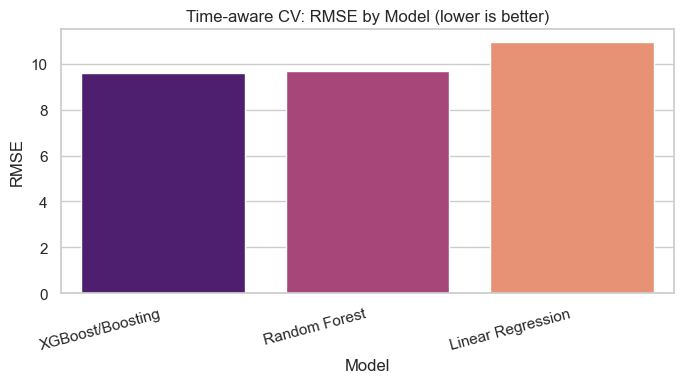

Saved: /Users/siamsadman/Git_Projects/git-projects/statistical_consulting_project/nfl_big_data_bowl_2026/nfl-yards-gained-prediction/figures/fig6_cv_rmse.png
Saved table: table6_timeseries_cv_folds.csv, table6_timeseries_cv_folds.tex


In [18]:
# 11.2) CV summary (mean over folds) + exports

cv_summary = cv_table.groupby("Model")[["MAE","RMSE","R2"]].mean().reset_index().sort_values("RMSE")
display(cv_summary)

save_table(cv_summary.round(3), "table6_cv_summary", index=False)

plt.figure(figsize=(7, 4))
sns.barplot(data=cv_summary, x="Model", y="RMSE", palette="magma")
plt.title("Time-aware CV: RMSE by Model (lower is better)")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig6_cv_rmse.png", dpi=300)
plt.show()

print("Saved:", FIG_DIR / "fig6_cv_rmse.png")

# CV fold boundaries table
fold_rows = []
for fold, (tr_idx, te_idx) in enumerate(tscv.split(X_all_raw), start=1):
    tr_min = df_sorted.iloc[tr_idx][sort_col].min()
    tr_max = df_sorted.iloc[tr_idx][sort_col].max()
    te_min = df_sorted.iloc[te_idx][sort_col].min()
    te_max = df_sorted.iloc[te_idx][sort_col].max()
    fold_rows.append({
        "Fold": fold,
        "Train_n": len(tr_idx),
        "Train_range": f"{tr_min} -- {tr_max}",
        "Test_n": len(te_idx),
        "Test_range": f"{te_min} -- {te_max}",
    })

cv_folds_table = pd.DataFrame(fold_rows)
save_table(cv_folds_table, "table6_timeseries_cv_folds", index=False, float_format="%.0f")


## 12. Interpretation: Feature Importance (Random Forest)

Tree-based models allow inspection of feature importance.  
Because categorical variables are one-hot encoded inside the pipeline, we extract expanded feature names.


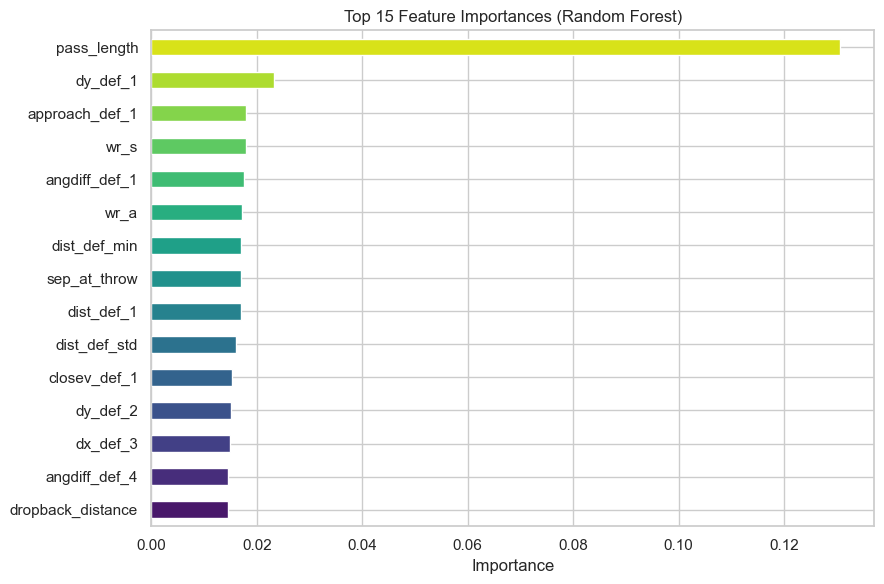

Saved: /Users/siamsadman/Git_Projects/git-projects/statistical_consulting_project/nfl_big_data_bowl_2026/nfl-yards-gained-prediction/figures/fig6_rf_importance.png


In [19]:
# 12.1) Fit RF on training set (for interpretation)

rf_model.fit(X_train_raw, y_train)

ohe = rf_model.named_steps["prep"].named_transformers_["cat"].named_steps["onehot"]
cat_feature_names = ohe.get_feature_names_out(cat_cols)
all_feature_names = np.concatenate([num_cols, cat_feature_names])

rf_est = rf_model.named_steps["model"]
importances = pd.Series(rf_est.feature_importances_, index=all_feature_names).sort_values(ascending=False)

top15 = importances.head(15).sort_values()
plt.figure(figsize=(9, 6))
top15.plot(kind="barh", color=sns.color_palette("viridis", 15))
plt.xlabel("Importance")
plt.title("Top 15 Feature Importances (Random Forest)")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig6_rf_importance.png", dpi=300)
plt.show()

print("Saved:", FIG_DIR / "fig6_rf_importance.png")


## 13. Final Interpretation (RQ2 & RQ3)

- **RQ2:** If route type (and route-related movement features) appears among important predictors and route groups differ in yards gained, this supports that **route design** is associated with play effectiveness.
- **RQ3:** If coverage indicators and defender pursuit/proximity features are important and man/zone distributions differ, this supports that **coverage scheme** influences play effectiveness.

The modeling results show how **strategy (route + coverage)** and **movement geometry** jointly explain yards gained.


## 14. Conclusion

This notebook completes the predictive modeling component for **RQ2 & RQ3**:

- We performed EDA + non-parametric statistical tests for route and coverage effects.
- We trained regression models to predict `yards_gained` using pre-throw features only.
- We validated models using time-aware **train/test split** and **rolling time-series CV**.
- We interpreted drivers of performance using feature importance.

**Next steps (optional):**
- add k-nearest defenders (k=3/5) and summary statistics across defenders
- hyperparameter tuning (grid/random search) for RF/XGBoost
- SHAP for more detailed interpretability
